In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
from huggingface_hub import notebook_login

notebook_login()

In [6]:
# train_wide = pd.read_csv('train_wide.csv')
# train_wide.head()

In [7]:
# train = pd.read_csv('eurorad_train.csv')
# train.head()

In [16]:
# Fix header detection so "B. Clinical Perspective" etc. are split anywhere (not only at line starts)
# Rebuild JSONL with correctly bolded, numbered headers in assistant.thinking.

import re, json, math
from pathlib import Path
from typing import List, Dict, Any, Optional
import pandas as pd
from datasets import load_dataset

EURORAD_CSV = "eurorad_train.csv"
WIDE_CSV    = "train_wide.csv"
OUT_JSONL   = Path("eurorad_train_messages_with_thinking.cleaned.v2.jsonl")

SYSTEM_PROMPT = (
    "You are a careful radiology diagnosis selector.\n"
    "Given a case description and a finite list of candidate diagnoses, "
    "select the single most likely final diagnosis FROM THE LIST.\n"
    "Response rules:\n"
    "1) Output EXACTLY one option, copied VERBATIM from the list.\n"
    "2) Output ONLY the diagnosis text. No explanation. No punctuation. No quotes.\n"
    "3) If uncertain, choose the closest match from the list. Never invent new options."
)
USER_TEMPLATE = (
    "{case_text}\n\n"
    "Candidate diagnoses (choose ONE):\n{options_block}\n\n"
    "Return exactly one option from the list above, copied verbatim."
)

# ---------- helpers ----------
def dedup_options(s: str) -> List[str]:
    opts = [o.strip() for o in (s or "").split(",") if o.strip()]
    seen, out = set(), []
    for o in opts:
        if o not in seen:
            seen.add(o); out.append(o)
    return out

def clean_ws(x: Optional[str]) -> str:
    x = (x or "").strip()
    if not x: return ""
    x = "\n".join(line.rstrip() for line in x.splitlines())
    return re.sub(r"\n{3,}", "\n\n", x).strip()

def strip_history_prefixes(desc: str) -> str:
    return re.sub(r"^\s*(Case description:|Clinical History:)\s*", "", desc, flags=re.IGNORECASE)

def pick_description(row: pd.Series) -> str:
    return strip_history_prefixes(clean_ws(row.get("PostDescription") or row.get("OriginalDescription") or ""))

def build_user_content(row: pd.Series) -> str:
    desc = pick_description(row)
    options = dedup_options(row.get("DifferentialDiagnosisList", ""))
    opts_block = "\n".join(f"- {o}" for o in options) if options else "- (no options provided)"
    return USER_TEMPLATE.format(case_text=desc, options_block=opts_block)

def to_json_serializable(x):
    if isinstance(x, float) and (math.isnan(x) or math.isinf(x)): return None
    return x

# ---------- header cleanup ----------
STD_HEADERS = [
    ("background", "Background"),
    ("clinical", "Clinical Perspective"),
    ("imaging", "Imaging Perspective"),
    ("outcome", "Outcome"),
    ("takehome", "Take Home Message / Teaching Points"),
]

PAT = {
    # allow anywhere, optional A./B./… markers, tolerate punctuation, commas, slashes
    "background": r"(?:^|[^A-Za-z])(?:A\.|A\)|I\.|\(A\))?\s*Background\b[: ]*",
    "clinical":   r"(?:^|[^A-Za-z])(?:B\.|B\)|II\.|\(B\))?\s*Clinical\s+Perspective\b[: ]*",
    "imaging":    r"(?:^|[^A-Za-z])(?:C\.|C\)|III\.|\(C\))?\s*Imaging\s+Perspective\b[: ]*",
    "outcome":    r"(?:^|[^A-Za-z])(?:D\.|D\)|IV\.|\(D\))?\s*Outcome\b[: ]*",
    "takehome":   r"(?:^|[^A-Za-z])(?:E\.|E\)|V\.|\(E\))?\s*(?:Take\s*Home\s*Message(?:\s*[/,]\s*Teaching\s*Points)?|Teaching\s*Points)\b[: ]*",
}

def remove_citations(text: str) -> str:
    text = re.sub(r"\[\s*\d+(?:\s*[-–]\s*\d+)?(?:\s*,\s*\d+(?:\s*[-–]\s*\d+)?)*\s*\]", "", text)
    text = re.sub(r"\s{2,}", " ", text)
    text = re.sub(r"\s+([.,;:])", r"\1", text)
    return text

def split_sections_anywhere(disc: str) -> Dict[str, str]:
    disc = remove_citations(clean_ws(disc))
    hits = []
    for key, pat in PAT.items():
        m = re.search(pat, disc, flags=re.IGNORECASE)
        if m:
            hits.append((m.start(), key, m.end()))
    if not hits:
        return {"background": disc}  # fallback: all in background
    hits.sort()
    parts = {}
    for i, (start, key, endpos) in enumerate(hits):
        nxt = hits[i+1][0] if i+1 < len(hits) else len(disc)
        parts[key] = clean_ws(disc[endpos:nxt])
    return parts

INTRO_LINE   = "Okay, let me analyze this case step by step to find the most likely option."
CLOSING_LINE = "Based on this, I will now choose a final answer from the provided list."

def format_discussion_clean(disc: str) -> str:
    parts = split_sections_anywhere(disc)
    chunks = [INTRO_LINE]  # start with your fixed opener

    # number only the sections that exist; drop take-home/teaching
    i = 1
    for key, header in STD_HEADERS:
        if key == "takehome":
            continue
        body = parts.get(key, "")
        if body:
            chunks.append(f"{i}. **{header}**\n{body}")
            i += 1

    if i == 1:  # no sections detected → put everything under Background
        chunks.append(f"1. **Background**\n{remove_citations(clean_ws(disc))}")

    chunks.append(CLOSING_LINE)  # fixed closing line
    return "\n\n".join(chunks)


# ---------- build ----------
narrow = pd.read_csv(EURORAD_CSV, dtype=str)
wide   = pd.read_csv(WIDE_CSV,   dtype=str)
if narrow.columns[0] != "case_id":
    narrow = narrow.rename(columns={narrow.columns[0]: "case_id"})
narrow["case_id"] = narrow["case_id"].astype(str).str.strip()
wide["case_id"]   = wide["case_id"].astype(str).str.strip()

merged = pd.merge(narrow, wide[["case_id","Discussion","URL"]], on="case_id", how="inner")

records = []
for _, row in merged.iterrows():
    thinking_raw = row.get("Discussion") or ""
    thinking_clean = format_discussion_clean(thinking_raw) if thinking_raw else None
    msgs = [
        {"role":"system", "content": SYSTEM_PROMPT, "thinking": None},
        {"role":"user",   "content": build_user_content(row), "thinking": None},
        {"role":"assistant", "content": str(row.get("FinalDiagnosis","")).strip(),
         "thinking": thinking_clean},
    ]
    records.append({
        "case_id": str(row["case_id"]).strip(),
        "url": str(row.get("URL", "")).strip(),
        "messages": msgs,
    })


OUT_JSONL.parent.mkdir(parents=True, exist_ok=True)
with OUT_JSONL.open("w", encoding="utf-8") as f:
    for ex in records:
        f.write(json.dumps(ex, ensure_ascii=False, default=to_json_serializable) + "\n")
print(f"Wrote {len(records)} -> {OUT_JSONL}")

# quick check
ds = load_dataset("json", data_files=str(OUT_JSONL))["train"]
print(json.dumps(ds[0], ensure_ascii=False, indent=2))


Wrote 1894 -> eurorad_train_messages_with_thinking.cleaned.v2.jsonl


Generating train split: 0 examples [00:00, ? examples/s]

{
  "case_id": "9908",
  "url": "https://www.eurorad.org/case/9908",
  "messages": [
    {
      "role": "system",
      "content": "You are a careful radiology diagnosis selector.\nGiven a case description and a finite list of candidate diagnoses, select the single most likely final diagnosis FROM THE LIST.\nResponse rules:\n1) Output EXACTLY one option, copied VERBATIM from the list.\n2) Output ONLY the diagnosis text. No explanation. No punctuation. No quotes.\n3) If uncertain, choose the closest match from the list. Never invent new options.",
      "thinking": null
    },
    {
      "role": "user",
      "content": "This patient presented subacutely with left thigh pain for two months, and had an outpatient plain pelvic radiograph. She later presented acutely to the hospital after a short interval of having \"heard a loud crack\" in the left leg, then fallen, with no preceding trauma. At this point repeat radiography was performed.\n\n Imaging Findings: The outpatient radiograph 

In [17]:
from huggingface_hub import HfApi
api = HfApi()
repo_id = "alif-munim/eurorad-train-thinking-v1"
api.create_repo(repo_id, repo_type="dataset", private=True, exist_ok=True)

api.upload_file(
    path_or_fileobj="eurorad_train_messages_with_thinking.cleaned.v2.jsonl",
    path_in_repo="data/train.jsonl",
    repo_id=repo_id,
    repo_type="dataset",
)
# api.upload_file(
#     path_or_fileobj="README.md",   # optional card
#     path_in_repo="README.md",
#     repo_id=repo_id,
#     repo_type="dataset",
# )


CommitInfo(commit_url='https://huggingface.co/datasets/alif-munim/eurorad-train-thinking-v1/commit/0f94c8d95096b70ac8f0b41499d7c0fccfeac92a', commit_message='Upload data/train.jsonl with huggingface_hub', commit_description='', oid='0f94c8d95096b70ac8f0b41499d7c0fccfeac92a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/alif-munim/eurorad-train-thinking-v1', endpoint='https://huggingface.co', repo_type='dataset', repo_id='alif-munim/eurorad-train-thinking-v1'), pr_revision=None, pr_num=None)

In [4]:
print(f"Size of final dataset: {len(ds)}")

Size of final dataset: 1894


In [5]:
# # ----- Load back with HF datasets (verifies format) -----
# ds = load_dataset("json", data_files=str(OUTPUT_PATH))["train"]
# print(ds)

# # Preview first example (as dict)
# ex0 = ds[0]
# print(json.dumps(ex0, ensure_ascii=False, indent=2)[:1000])

# # Quick sanity checks
# assert "messages" in ex0 and isinstance(ex0["messages"], list) and len(ex0["messages"]) >= 3
# assert ex0["messages"][0]["role"] == "system"
# assert ex0["messages"][1]["role"] == "user"
# assert ex0["messages"][-1]["role"] == "assistant"

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("openai/gpt-oss-20b")

In [7]:
import torch
from transformers import AutoModelForCausalLM, Mxfp4Config

quantization_config = Mxfp4Config(dequantize=True)
model_kwargs = dict(
    attn_implementation="eager",
    torch_dtype=torch.bfloat16,
    quantization_config=quantization_config,
    use_cache=False,
    device_map="auto",
)

model = AutoModelForCausalLM.from_pretrained("openai/gpt-oss-20b", **model_kwargs)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [8]:
messages = [
    {"role": "user", "content": "This patient presented subacutely with left thigh pain for two months, and had an outpatient plain pelvic radiograph. She later presented acutely to the hospital after a short interval of having \"heard a loud crack\" in the left leg, then fallen, with no preceding trauma. At this point repeat radiography was performed.\n\n Imaging Findings: The outpatient radiograph was initially assessed as normal. Although indeed not demonstrating any femoral or pelvic fracture, it did in fact show focal cortical thickening of the left lateral proximal femur. At this site, one week later, a complete transverse fracture of the proximal femur was seen with some displacement, with features consistent with atypical femoral fracture.\n\nCandidate diagnoses (choose ONE):\n- Insufficiency fracture\n- Pathological fracture\n- Bisphosphonate-associated atypical femoral fracture with preceding cortical reaction\n\nReturn exactly one option from the list above, copied verbatim."},
]

input_ids = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    return_tensors="pt",
).to(model.device)

output_ids = model.generate(input_ids, max_new_tokens=512)
response = tokenizer.batch_decode(output_ids)[0]
print(response)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-09-02

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>This patient presented subacutely with left thigh pain for two months, and had an outpatient plain pelvic radiograph. She later presented acutely to the hospital after a short interval of having "heard a loud crack" in the left leg, then fallen, with no preceding trauma. At this point repeat radiography was performed.

 Imaging Findings: The outpatient radiograph was initially assessed as normal. Although indeed not demonstrating any femoral or pelvic fracture, it did in fact show focal cortical thickening of the left lateral proximal femur. At this site, one week later, a complete transverse fracture of the proximal femur was seen with some displacement, with features consistent with atypical femoral fracture.

C

In [9]:
from peft import LoraConfig, get_peft_model

peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules="all-linear",
    target_parameters=[
        "7.mlp.experts.gate_up_proj",
        "7.mlp.experts.down_proj",
        "15.mlp.experts.gate_up_proj",
        "15.mlp.experts.down_proj",
        "23.mlp.experts.gate_up_proj",
        "23.mlp.experts.down_proj",
    ],
)
peft_model = get_peft_model(model, peft_config)
peft_model.print_trainable_parameters()

trainable params: 15,040,512 || all params: 20,929,797,696 || trainable%: 0.0719


/home/sagemaker-user/.conda/envs/oss/lib/python3.12/site-packages/peft/tuners/lora/layer.py:159: UserWarning: Unsupported layer type '<class 'transformers.models.gpt_oss.modeling_gpt_oss.GptOssExperts'>' encountered, proceed at your own risk.
  warnings.warn(


In [10]:
from trl import SFTConfig

training_args = SFTConfig(
    learning_rate=2e-4,
    gradient_checkpointing=True,
    num_train_epochs=1,
    logging_steps=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    max_length=2048,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine_with_min_lr",
    lr_scheduler_kwargs={"min_lr_rate": 0.1},
    output_dir="gpt-oss-20b-eurorad-discussion-v1",
    report_to="trackio",
    push_to_hub=True,
)

In [11]:
from trl import SFTTrainer

# Build trainer
trainer = SFTTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=ds,
    processing_class=tokenizer,
)

trainer.train()

Tokenizing train dataset:   0%|          | 0/1894 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1894 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 199998}.


* Trackio project initialized: huggingface
* Trackio metrics logged to: /home/sagemaker-user/.cache/huggingface/trackio
* View dashboard by running in your terminal:
trackio show --project "huggingface"
* or by running in Python: trackio.show(project="huggingface")


Step,Training Loss
1,5.510300
2,5.115300
3,5.442300
4,4.785800
5,3.936400
6,2.961300
7,2.754800
8,2.614300
9,2.287200
10,2.095400


* Run finished. Uploading logs to Trackio Space: http://127.0.0.1:7860/ (please wait...)


TrainOutput(global_step=119, training_loss=1.7326950796511995, metrics={'train_runtime': 2540.5927, 'train_samples_per_second': 0.745, 'train_steps_per_second': 0.047, 'total_flos': 2.6194113289139328e+17, 'train_loss': 1.7326950796511995, 'epoch': 1.0})

# Custom

In [12]:
print("hello")

hello


In [13]:
%matplotlib inline

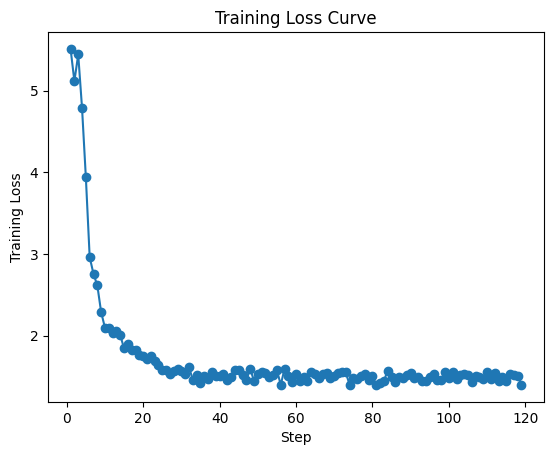

In [14]:
# !pip install matplotlib --quiet
import matplotlib.pyplot as plt

logs = trainer.state.log_history

steps = [entry["step"] for entry in logs if "loss" in entry]
losses = [entry["loss"] for entry in logs if "loss" in entry]

plt.plot(steps, losses, marker="o")
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.show()


In [15]:
trainer.save_model(training_args.output_dir)
trainer.push_to_hub(dataset_name="alif-munim/eurorad-discussion-v1")

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...rad-discussion-v1/training_args.bin: 100%|##########| 6.22kB / 6.22kB            

  ...urorad-discussion-v1/tokenizer.json: 100%|##########| 27.9MB / 27.9MB            

  ...ussion-v1/adapter_model.safetensors:  84%|########3 | 50.3MB / 60.2MB            

...

New Data Upload                         : |          |  0.00B /  0.00B            

  ...rad-discussion-v1/training_args.bin: 100%|##########| 6.22kB / 6.22kB            

  ...urorad-discussion-v1/tokenizer.json: 100%|##########| 27.9MB / 27.9MB            

  ...ussion-v1/adapter_model.safetensors:  84%|########3 | 50.3MB / 60.2MB            

CommitInfo(commit_url='https://huggingface.co/alif-munim/gpt-oss-20b-eurorad-discussion-v1/commit/8935ce865726e84235acbbc5d42127821e00f45a', commit_message='End of training', commit_description='', oid='8935ce865726e84235acbbc5d42127821e00f45a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/alif-munim/gpt-oss-20b-eurorad-discussion-v1', endpoint='https://huggingface.co', repo_type='model', repo_id='alif-munim/gpt-oss-20b-eurorad-discussion-v1'), pr_revision=None, pr_num=None)

# Inference

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch

MODEL_ID = "openai/gpt-oss-20b"
ADAPTER_ID = "gpt-oss-20b-eurorad-discussion-v1"
DEVICE = "cuda:0"

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "left"

# Base model on a single GPU (no auto-sharding)
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    attn_implementation="eager",
    torch_dtype=torch.bfloat16,   # or "auto"
    device_map=None,              # critical: don't shard
)
base_model.to(DEVICE)
base_model.eval()

# Attach LoRA, then merge and keep on same device
model = PeftModel.from_pretrained(base_model, ADAPTER_ID)
model = model.merge_and_unload()         # merges weights into base_model
model.to(DEVICE)
model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!
MXFP4 quantization requires triton >= 3.4.0 and kernels installed, we will default to dequantizing the model to bf16


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/home/sagemaker-user/.conda/envs/oss/lib/python3.12/site-packages/peft/tuners/lora/layer.py:159: UserWarning: Unsupported layer type '<class 'transformers.models.gpt_oss.modeling_gpt_oss.GptOssExperts'>' encountered, proceed at your own risk.
  warnings.warn(


GptOssForCausalLM(
  (model): GptOssModel(
    (embed_tokens): Embedding(201088, 2880, padding_idx=199999)
    (layers): ModuleList(
      (0-23): 24 x GptOssDecoderLayer(
        (self_attn): GptOssAttention(
          (q_proj): Linear(in_features=2880, out_features=4096, bias=True)
          (k_proj): Linear(in_features=2880, out_features=512, bias=True)
          (v_proj): Linear(in_features=2880, out_features=512, bias=True)
          (o_proj): Linear(in_features=4096, out_features=2880, bias=True)
        )
        (mlp): GptOssMLP(
          (router): GptOssTopKRouter()
          (experts): GptOssExperts()
        )
        (input_layernorm): GptOssRMSNorm((2880,), eps=1e-05)
        (post_attention_layernorm): GptOssRMSNorm((2880,), eps=1e-05)
      )
    )
    (norm): GptOssRMSNorm((2880,), eps=1e-05)
    (rotary_emb): GptOssRotaryEmbedding()
  )
  (lm_head): Linear(in_features=2880, out_features=201088, bias=False)
)

In [5]:
def get_response(model, tokenizer, device, sys, usr):
    
    SYSTEM_PROMPT = sys
    USER_PROMPT = usr
    DEVICE = device
    
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": USER_PROMPT},
    ]
    
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
    ).to(DEVICE)
    
    gen_kwargs = dict(
        max_new_tokens=1024,
        do_sample=True,
        temperature=0.6,
    )
    
    with torch.inference_mode():
        output_ids = model.generate(inputs, **gen_kwargs)
    
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

In [6]:
SYSTEM_PROMPT = "You are a careful radiology diagnosis selector.\nGiven a case description and a finite list of candidate diagnoses, select the single most likely final diagnosis FROM THE LIST.\nResponse rules:\n1) Output EXACTLY one option, copied VERBATIM from the list.\n2) Output ONLY the diagnosis text. No explanation. No punctuation. No quotes.\n3) If uncertain, choose the closest match from the list. Never invent new options."
# USER_PROMPT = "This patient presented subacutely with left thigh pain for two months, and had an outpatient plain pelvic radiograph. She later presented acutely to the hospital after a short interval of having \"heard a loud crack\" in the left leg, then fallen, with no preceding trauma. At this point repeat radiography was performed.\n\n Imaging Findings: The outpatient radiograph was initially assessed as normal. Although indeed not demonstrating any femoral or pelvic fracture, it did in fact show focal cortical thickening of the left lateral proximal femur. At this site, one week later, a complete transverse fracture of the proximal femur was seen with some displacement, with features consistent with atypical femoral fracture.\n\nCandidate diagnoses (choose ONE):\n- Insufficiency fracture\n- Pathological fracture\n- Bisphosphonate-associated atypical femoral fracture with preceding cortical reaction\n\nReturn exactly one option from the list above, copied verbatim."
USER_PROMPT = """
Clinical History: An 81-year-old male with a history of paroxysmal atrial fibrillation presents to the emergency department with a one-week onset of orthopnoea and exertional dyspnoea. Laboratory tests demonstrate elevated troponins, the electrocardiogram reveals a third-degree atrioventricular block, and the echocardiogram shows right ventricular thickening and pericardial effusion.
Imaging Findings: A PET-CT scan was carried out revealing a large hypermetabolic myocardial tissue. It extended through the right chambers and around the large vessels, sparing the left ventricle. Additionally, a hypermetabolic nodular image was identified at the left lung base. Therefore, a contrast-enhanced chest CT scan was performed. It confirmed the presence of an infiltrative hypodense mass in the myocardium. It involved the right atrium, right ventricle, interatrial septum, and atrioventricular groove. The mass caused mural thickening of the right cavities. A cuff encircled the right coronary artery along its course. A moderate pericardial effusion was also observed. Finally, the CT scan confirmed the solid nodule in the posterior segment of the left lower lobe. A CT-guided percutaneous biopsy of the lung nodule was made for histological examination.
Candidate diagnoses (choose ONE): Angiosarcoma, Ig-G4 related disease, Primary cardiac lymphoma, Erdheim–Chester disease, Undifferentiated pleomorphic sarcoma
"""

resp = get_response(model, tokenizer, DEVICE, SYSTEM_PROMPT, USER_PROMPT)

In [8]:
print(resp)

systemYou are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-09-03

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.developer# Instructions

You are a careful radiology diagnosis selector.
Given a case description and a finite list of candidate diagnoses, select the single most likely final diagnosis FROM THE LIST.
Response rules:
1) Output EXACTLY one option, copied VERBATIM from the list.
2) Output ONLY the diagnosis text. No explanation. No punctuation. No quotes.
3) If uncertain, choose the closest match from the list. Never invent new options.

user
Clinical History: An 81-year-old male with a history of paroxysmal atrial fibrillation presents to the emergency department with a one-week onset of orthopnoea and exertional dyspnoea. Laboratory tests demonstrate elevated troponins, the electrocardiogram reveals a third-degree atrioventricular block, and the echocardiogram sho

In [7]:
import re

def extract_after_assistantfinal(text: str) -> str:
    """
    Returns everything after the last occurrence of 'assistantfinal'.
    Strips leading/trailing whitespace. Empty string if not found.
    """
    m = re.search(r"assistantfinal\s*(.*)\Z", text, flags=re.S)
    return m.group(1).strip() if m else ""

In [9]:
ans = extract_after_assistantfinal(resp)
print(ans)  # -> Erdheim–Chester disease

Erdheim–Chester disease


# Eval Batch

In [14]:
"""
Full updated script:
- Multi-GPU sharded loading (uses all visible GPUs via device_map="balanced")
- Batched inference with tqdm
- Prints per-row RAW prompt+completion, extracted answer, and ground truth
- Saves model_answer, model_raw, model_correct to CSV and prints accuracy
"""

import os, re, difflib
import pandas as pd
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# -------------------- Config --------------------
MODEL_ID    = "openai/gpt-oss-20b"
ADAPTER_ID  = None                      # e.g. "gpt-oss-20b-multilingual-reasoner" or None
DTYPE       = torch.bfloat16            # ignored if USE_4BIT=True
USE_4BIT    = False                     # set True to increase batch size (requires bitsandbytes)
BATCH_SIZE  = 8                        # increase until nvidia-smi shows ~80–90% util
MAX_NEW_TOK = 2048                        # small completions for classification
INPUT_CSV   = "eurorad_test.csv"
OUTPUT_CSV  = "cases_with_model.csv"

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"]  = "false"
assert torch.cuda.is_available() and torch.cuda.device_count() >= 2, "Need >=2 GPUs for sharding."

# -------------------- GPU memory map --------------------
def _gib(nbytes):  # ~90% of VRAM per GPU to encourage spreading across all devices
    return f"{max(1, int(nbytes / (1024**3) * 0.90))}GiB"

max_memory = {i: _gib(torch.cuda.get_device_properties(i).total_memory)
              for i in range(torch.cuda.device_count())}
max_memory["cpu"] = "160GiB"

# -------------------- Tokenizer --------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "left"

# -------------------- Model --------------------
model_kwargs = dict(
    trust_remote_code=True,
    torch_dtype=None if USE_4BIT else DTYPE,
    device_map="balanced",            # spreads layers across all GPUs
    max_memory=max_memory,
    low_cpu_mem_usage=True,
    attn_implementation="eager",      # use "flash_attention_2" if your stack supports it
)

if USE_4BIT:
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    model_kwargs["quantization_config"] = quantization_config

base_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kwargs)
model = base_model
if ADAPTER_ID:
    from peft import PeftModel
    model = PeftModel.from_pretrained(base_model, ADAPTER_ID, is_trainable=False)
model.eval()

FIRST_CUDA = next(p.device for p in model.parameters() if p.is_cuda)

# -------------------- Prompts --------------------
SYSTEM_PROMPT = (
    "You are a careful radiology diagnosis selector.\n"
    "Given a case description and a finite list of candidate diagnoses, select the single most likely final diagnosis FROM THE LIST.\n"
    "Response rules:\n"
    "1) Output EXACTLY one option, copied VERBATIM from the list.\n"
    "2) Output ONLY the diagnosis text. No explanation. No punctuation. No quotes.\n"
    "3) If uncertain, choose the closest match from the list. Never invent new options."
)

def build_user_prompt(desc, ddx_list):
    return f"""{desc}

Candidate diagnoses (choose ONE): {ddx_list}
"""

# Prefer PostDescription; fall back to OriginalDescription
def choose_desc(row: dict) -> str:
    d = row.get("PostDescription")
    if isinstance(d, float) and pd.isna(d):
        d = None
    return d if (d and str(d).strip()) else row.get("OriginalDescription", "")

# -------------------- Extraction helpers --------------------
def extract_after_assistantfinal(text: str) -> str:
    m = re.search(r"assistantfinal\s*(.*)\Z", text, flags=re.S)
    return m.group(1).strip() if m else ""

def pick_option_from_text(text: str, options):
    tail = extract_after_assistantfinal(text)
    cand = tail.splitlines()[0].strip().lstrip("-• ").strip() if tail else ""
    norm = lambda s: re.sub(r"\s+", " ", str(s)).strip()
    for opt in options:
        if norm(cand).lower() == norm(opt).lower(): return opt
    for opt in options:
        if norm(cand).lower().startswith(norm(opt).lower()): return opt
    for opt in options:
        if re.search(rf"\b{re.escape(opt)}\b", cand, flags=re.I): return opt
    for opt in options:
        if re.search(rf"\b{re.escape(opt)}\b", text, flags=re.I): return opt
    best = difflib.get_close_matches(cand or text, options, n=1, cutoff=0.0)
    return best[0] if best else ""

_norm = lambda s: re.sub(r"\s+", " ", str(s)).strip().lower()

# -------------------- Data --------------------
df = pd.read_csv(INPUT_CSV, sep=None, engine="python")

answers, raws, correct_flags = [], [], []
total = len(df)

# -------------------- Batched inference --------------------
for start in tqdm(range(0, total, BATCH_SIZE), desc="Scoring", total=(total + BATCH_SIZE - 1)//BATCH_SIZE):
    batch = df.iloc[start:start + BATCH_SIZE]

    # 1) Build serialized prompts (strings) per row
    prompt_texts, ddx_lists, case_ids, gts = [], [], [], []
    for _, row in batch.iterrows():
        rowd = row.to_dict()
        desc = choose_desc(rowd)
        ddx  = str(rowd.get("DifferentialDiagnosisList", "") or "")
        gt   = str(rowd.get("FinalDiagnosis", "") or "").strip()
        gts.append(gt)
        case_ids.append(rowd.get("case_id", "NA"))
        ddx_lists.append([o.strip() for o in ddx.split(",") if o.strip()])

        msgs = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": build_user_prompt(desc, ddx)},
        ]
        prompt_texts.append(
            tokenizer.apply_chat_template(msgs, add_generation_prompt=True, tokenize=False)
        )

    # 2) Tokenize prompts to get input_ids + attention_mask
    batch_inputs = tokenizer(
        prompt_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    )
    batch_inputs = {k: v.to(FIRST_CUDA) for k, v in batch_inputs.items()}
    input_lens = batch_inputs["attention_mask"].sum(dim=1).tolist()

    # 3) Generate
    gen_kwargs = dict(
        max_new_tokens=MAX_NEW_TOK,
        do_sample=False,
        temperature=0.0,
        pad_token_id=tokenizer.eos_token_id,
        use_cache=True,
    )
    with torch.inference_mode():
        out_ids = model.generate(**batch_inputs, **gen_kwargs)

    # 4) Decode and extract
    for i in range(len(batch)):
        comp_ids  = out_ids[i, input_lens[i]:]
        comp_text = tokenizer.decode(comp_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)
        raw_pc    = prompt_texts[i] + comp_text
        raws.append(raw_pc)

        full_text = tokenizer.decode(out_ids[i], skip_special_tokens=True, clean_up_tokenization_spaces=False)
        opts = ddx_lists[i]
        ans = pick_option_from_text(full_text, opts) if opts else comp_text.strip()
        answers.append(ans)

        gt = gts[i]
        is_correct = _norm(ans) == _norm(gt)
        correct_flags.append(bool(is_correct))

        # Print
        tqdm.write(f"[case_id={case_ids[i]}] --- RAW PROMPT+COMPLETION ---\n{raw_pc}")
        tqdm.write(f"[case_id={case_ids[i]}] --- EXTRACTED ---\n{ans}")
        tqdm.write(f"[case_id={case_ids[i]}] --- GROUND TRUTH ---\n{gt}")
        tqdm.write(f"[case_id={case_ids[i]}] --- MATCH --- {'CORRECT' if is_correct else 'WRONG'}")
        tqdm.write("-" * 60)

# -------------------- Save + metrics --------------------
out = df.copy()
out["model_answer"]  = answers
out["model_raw"]     = raws
out["model_correct"] = correct_flags
out.to_csv(OUTPUT_CSV, index=False)

acc = sum(correct_flags) / max(1, len(correct_flags))
print(f"Wrote {OUTPUT_CSV} | Accuracy: {acc:.3f} ({sum(correct_flags)}/{len(correct_flags)})")


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Scoring:   4%|▎         | 1/27 [01:16<33:11, 76.60s/it]

[case_id=18812] --- RAW PROMPT+COMPLETION ---
<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-09-03

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>developer<|message|># Instructions

You are a careful radiology diagnosis selector.
Given a case description and a finite list of candidate diagnoses, select the single most likely final diagnosis FROM THE LIST.
Response rules:
1) Output EXACTLY one option, copied VERBATIM from the list.
2) Output ONLY the diagnosis text. No explanation. No punctuation. No quotes.
3) If uncertain, choose the closest match from the list. Never invent new options.

<|end|><|start|>user<|message|>Clinical History: A 46-year-old male patient, with a known history of human immunodeficiency virus and hepatitis C virus coinfection, underwent a computed tomography (CT) to assess liver lesions detected by US,

Scoring:   7%|▋         | 2/27 [02:05<25:12, 60.48s/it]

[case_id=18832] --- RAW PROMPT+COMPLETION ---
<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-09-03

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>developer<|message|># Instructions

You are a careful radiology diagnosis selector.
Given a case description and a finite list of candidate diagnoses, select the single most likely final diagnosis FROM THE LIST.
Response rules:
1) Output EXACTLY one option, copied VERBATIM from the list.
2) Output ONLY the diagnosis text. No explanation. No punctuation. No quotes.
3) If uncertain, choose the closest match from the list. Never invent new options.

<|end|><|start|>user<|message|>Clinical History: A 55-year-old female patient was admitted to our oncology centre with follicular lymphoma. She had a seven-kilogram weight loss over one year, loss of appetite, and fever of unknown origin. Th

...

[case_id=19143] --- RAW PROMPT+COMPLETION ---
<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-09-03

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>developer<|message|># Instructions

You are a careful radiology diagnosis selector.
Given a case description and a finite list of candidate diagnoses, select the single most likely final diagnosis FROM THE LIST.
Response rules:
1) Output EXACTLY one option, copied VERBATIM from the list.
2) Output ONLY the diagnosis text. No explanation. No punctuation. No quotes.
3) If uncertain, choose the closest match from the list. Never invent new options.

<|end|><|start|>user<|message|>Clinical History: A 20-year-old male presented with worsening lower back pain for 6 months. On physical examination there was no deformity or neurological deficits noted. There was no history of fever, night sw

Scoring:  96%|█████████▋| 26/27 [19:18<00:52, 52.86s/it]

[case_id=19156] --- RAW PROMPT+COMPLETION ---
<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-09-03

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>developer<|message|># Instructions

You are a careful radiology diagnosis selector.
Given a case description and a finite list of candidate diagnoses, select the single most likely final diagnosis FROM THE LIST.
Response rules:
1) Output EXACTLY one option, copied VERBATIM from the list.
2) Output ONLY the diagnosis text. No explanation. No punctuation. No quotes.
3) If uncertain, choose the closest match from the list. Never invent new options.

<|end|><|start|>user<|message|>Clinical History: A 14-year-old male cricket player presented with anterior knee pain for 3 months, aggravated by jumping and stair climbing. No history of trauma or systemic symptoms. Localised tenderness was 

Scoring: 100%|██████████| 27/27 [19:26<00:00, 43.20s/it]

[case_id=19164] --- RAW PROMPT+COMPLETION ---
<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-09-03

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>developer<|message|># Instructions

You are a careful radiology diagnosis selector.
Given a case description and a finite list of candidate diagnoses, select the single most likely final diagnosis FROM THE LIST.
Response rules:
1) Output EXACTLY one option, copied VERBATIM from the list.
2) Output ONLY the diagnosis text. No explanation. No punctuation. No quotes.
3) If uncertain, choose the closest match from the list. Never invent new options.

<|end|><|start|>user<|message|>Clinical History: Case 1: A 9-year-old girl presented to the otorhinolaryngology (ENT) department with profound hearing loss. On evaluation, she was detected to have right-sided sensorineural hearing loss (SNHL

# Eval 2

In [12]:
"""
Batch inference with tqdm, printing per-iteration outputs, and using all 8 GPUs.

Requirements:
- Load your model sharded across GPUs (device_map="auto"). Example loader is included.
- Uses your existing get_response() and extract_after_assistantfinal() helpers.
"""

import os
import re
import difflib
import pandas as pd
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

# -----------------------------
# (A) Load model on all 8 GPUs
# -----------------------------
MODEL_ID   = "openai/gpt-oss-20b"
ADAPTER_ID = None  # e.g., "gpt-oss-20b-multilingual-reasoner" or None
DTYPE      = torch.bfloat16  # or "auto"

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
assert torch.cuda.device_count() >= 2, "This script expects multiple GPUs."

# Build max_memory for each visible GPU (90% of total)
def _gib(nbytes):  # -> "XXGiB"
    return f"{max(1, int(nbytes / (1024**3) * 0.90))}GiB"
max_memory = {i: _gib(torch.cuda.get_device_properties(i).total_memory)
              for i in range(torch.cuda.device_count())}
max_memory["cpu"] = "160GiB"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "left"

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    torch_dtype=DTYPE,
    device_map="auto",            # <- sharded across all GPUs
    max_memory=max_memory,
    low_cpu_mem_usage=True,
    attn_implementation="eager",
)

model = base_model
if ADAPTER_ID:
    # Attach LoRA without merging (keeps memory low, uses sharded base)
    model = PeftModel.from_pretrained(base_model, ADAPTER_ID, is_trainable=False)
model.eval()

# First CUDA device for putting inputs (works with sharded models)
FIRST_CUDA = next(p.device for p in model.parameters() if p.is_cuda)

# -----------------------------
# (B) Your given helpers
# -----------------------------
def get_response(model, tokenizer, device, sys, usr):
    SYSTEM_PROMPT = sys
    USER_PROMPT = usr
    DEVICE = device

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": USER_PROMPT},
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
    ).to(DEVICE)

    gen_kwargs = dict(
        max_new_tokens=512,
        do_sample=False,         # deterministic for classification
        temperature=0.0,
        pad_token_id=tokenizer.eos_token_id,
    )

    with torch.inference_mode():
        output_ids = model.generate(inputs, **gen_kwargs)

    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

def extract_after_assistantfinal(text: str) -> str:
    m = re.search(r"assistantfinal\s*(.*)\Z", text, flags=re.S)
    return m.group(1).strip() if m else ""

# Robust option picker (handles noisy outputs)
def pick_option_from_text(text: str, options):
    tail = extract_after_assistantfinal(text)
    cand = tail.splitlines()[0].strip().lstrip("-• ").strip() if tail else ""

    def norm(s): return re.sub(r"\s+", " ", s).strip()

    for opt in options:
        if norm(cand) == norm(opt): return opt
    for opt in options:
        if norm(cand).startswith(norm(opt)): return opt
    for opt in options:
        if re.search(rf"\b{re.escape(opt)}\b", cand): return opt
    for opt in options:
        if re.search(rf"\b{re.escape(opt)}\b", text): return opt

    best = difflib.get_close_matches(cand or text, options, n=1, cutoff=0.0)
    return best[0] if best else ""

def build_user_prompt(row):
    # Prefer PostDescription; fall back to OriginalDescription.
    desc = getattr(row, "PostDescription", None)
    if desc is None or (isinstance(desc, float) and pd.isna(desc)) or not str(desc).strip():
        desc = getattr(row, "OriginalDescription", "")
    ddx_list = getattr(row, "DifferentialDiagnosisList", "")
    return f"""{desc}

Candidate diagnoses (choose ONE): {ddx_list}
"""

SYSTEM_PROMPT = (
    "You are a careful radiology diagnosis selector.\n"
    "Given a case description and a finite list of candidate diagnoses, select the single most likely final diagnosis FROM THE LIST.\n"
    "Response rules:\n"
    "1) Output EXACTLY one option, copied VERBATIM from the list.\n"
    "2) Output ONLY the diagnosis text. No explanation. No punctuation. No quotes.\n"
    "3) If uncertain, choose the closest match from the list. Never invent new options."
)

# -----------------------------
# (C) Batch over CSV with tqdm
# -----------------------------
INPUT_CSV  = "eurorad_test.csv"                 # path to your input
OUTPUT_CSV = "cases_with_model.csv"      # will be written
df = pd.read_csv(INPUT_CSV, sep=None, engine="python")

model_answers = []
raw_texts = []

for row in tqdm(df.itertuples(index=False), total=len(df), desc="Scoring"):
    # Build prompts
    user_prompt = build_user_prompt(row)

    # Optional: print the prompt (clean, no tags)
    # If you want the serialized chat template for the prompt, uncomment:
    # prompt_text = tokenizer.apply_chat_template(
    #     [{"role": "system", "content": SYSTEM_PROMPT},
    #      {"role": "user", "content": user_prompt}],
    #     add_generation_prompt=True,
    #     tokenize=False,
    # )

    # Call model (sharded across all GPUs)
    decoded = get_response(model, tokenizer, FIRST_CUDA, SYSTEM_PROMPT, user_prompt)
    raw_texts.append(decoded)

    # Extract final option
    options = [o.strip() for o in getattr(row, "DifferentialDiagnosisList", "").split(",") if o.strip()]
    ans = pick_option_from_text(decoded, options) if options else extract_after_assistantfinal(decoded)
    model_answers.append(ans)

    # ---- Print per-iteration (prompt+completion + extracted) ----
    tqdm.write(f"[case_id={getattr(row, 'case_id', 'NA')}]")
    # If you saved prompt_text above, you can print it here for full prompt+completion view:
    # tqdm.write("--- PROMPT ---\n" + prompt_text)
    tqdm.write("--- MODEL OUTPUT ---\n" + decoded)
    tqdm.write("--- EXTRACTED ANSWER ---\n" + (ans or "<empty>"))
    tqdm.write("-" * 60)

# Save
out = df.copy()
out["model_answer"] = model_answers
# out["model_raw"] = raw_texts  # keep for debugging if desired
out.to_csv(OUTPUT_CSV, index=False)
print(f"Wrote {OUTPUT_CSV}")


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Scoring:   0%|          | 0/209 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Scoring:   0%|          | 1/209 [00:18<1:02:30, 18.03s/it]

[case_id=18812]
--- MODEL OUTPUT ---
systemYou are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-09-03

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.developer# Instructions

You are a careful radiology diagnosis selector.
Given a case description and a finite list of candidate diagnoses, select the single most likely final diagnosis FROM THE LIST.
Response rules:
1) Output EXACTLY one option, copied VERBATIM from the list.
2) Output ONLY the diagnosis text. No explanation. No punctuation. No quotes.
3) If uncertain, choose the closest match from the list. Never invent new options.

userClinical History: A 46-year-old male patient, with a known history of human immunodeficiency virus and hepatitis C virus coinfection, underwent a computed tomography (CT) to assess liver lesions detected by US, which were later identified as haemangiomas. On physical examination, hypoplastic 

Scoring:   0%|          | 1/209 [00:33<1:54:49, 33.12s/it]


KeyboardInterrupt: 

# Evaluate

In [11]:
# --- robust option picker (fallbacks if the tag isn't present) ---
def pick_option_from_text(text: str, options):
    # 1) try after 'assistantfinal'
    tail = extract_after_assistantfinal(text)
    cand = tail.splitlines()[0].strip().lstrip("-• ").strip() if tail else ""

    # helpers
    def norm(s): return re.sub(r"\s+", " ", s).strip()

    # 2) exact / prefix / containment
    for opt in options:
        if norm(cand) == norm(opt): return opt
    for opt in options:
        if norm(cand).startswith(norm(opt)): return opt
    for opt in options:
        if re.search(rf"\b{re.escape(opt)}\b", cand): return opt

    # 3) search the whole decoded text for an option
    for opt in options:
        if re.search(rf"\b{re.escape(opt)}\b", text): return opt

    # 4) fuzzy fallback
    best = difflib.get_close_matches(cand or text, options, n=1, cutoff=0.0)
    return best[0] if best else ""

# --- build the user prompt from a row ---
def build_user_prompt(row):
    desc = row.get("PostDescription") if isinstance(row, dict) else getattr(row, "PostDescription", None)
    if not desc or pd.isna(desc):
        desc = row.get("OriginalDescription") if isinstance(row, dict) else getattr(row, "OriginalDescription", "")
    ddx_list = row.get("DifferentialDiagnosisList") if isinstance(row, dict) else getattr(row, "DifferentialDiagnosisList", "")
    return f"""{desc}

Candidate diagnoses (choose ONE): {ddx_list}
"""

In [13]:
import os
import re
import difflib
import pandas as pd
from tqdm import tqdm
import torch

In [14]:
SYSTEM_PROMPT = (
    "You are a careful radiology diagnosis selector.\n"
    "Given a case description and a finite list of candidate diagnoses, select the single most likely final diagnosis FROM THE LIST.\n"
    "Response rules:\n"
    "1) Output EXACTLY one option, copied VERBATIM from the list.\n"
    "2) Output ONLY the diagnosis text. No explanation. No punctuation. No quotes.\n"
    "3) If uncertain, choose the closest match from the list. Never invent new options."
)

# -------- batch runner with tqdm --------
INPUT_CSV  = "eurorad_test.csv"          # set your path
OUTPUT_CSV = "eurorad_test_oss20b_ft.csv"

# Let pandas sniff the delimiter (handles CSV or TSV)
df = pd.read_csv(INPUT_CSV, sep=None, engine="python")

# Determine a good device handle for sharded models
try:
    FIRST_CUDA = next(p.device for p in model.parameters() if p.is_cuda)
except StopIteration:
    FIRST_CUDA = torch.device("cpu")

model_answers = []
raw_texts = []   # optional: keep raw for debugging; remove if you only want the final column

for row in tqdm(df.itertuples(index=False), total=len(df), desc="Scoring"):
    user_prompt = build_user_prompt(row)

    # call model
    decoded = get_response(model, tokenizer, FIRST_CUDA, SYSTEM_PROMPT, user_prompt)
    raw_texts.append(decoded)

    # options list
    options = [o.strip() for o in getattr(row, "DifferentialDiagnosisList", "").split(",") if o.strip()]

    # extract final answer
    ans = pick_option_from_text(decoded, options) if options else extract_after_assistantfinal(decoded)
    model_answers.append(ans)

df = df.copy()
df["model_answer"] = model_answers
# df["model_raw"] = raw_texts  # uncomment if you want the raw output too

df.to_csv(OUTPUT_CSV, index=False)
print(f"Wrote {OUTPUT_CSV}")

Scoring:   0%|          | 1/209 [00:32<1:52:50, 32.55s/it]


KeyboardInterrupt: 